# 12 · Stats & results dashboard

A single place to see the corpus, the metadata catalogue, cover sourcing, and batch results. Every section **degrades gracefully** — run what you have data for; sections with no data print a hint instead of failing.

Set `CONFIG` to the deployment you're inspecting (local test vs production).

In [2]:
from pathlib import Path
import pandas as pd
import plotly.express as px

from evilflowers_books_digitalizer.runtime import load_runtime, build_catalog
from evilflowers_books_digitalizer import reporting

CONFIG = '../configs/pipeline.local.toml'   # or 'configs/pipeline.toml' on the VM
rt = load_runtime(CONFIG)
print('output_dir:', rt.output_dir)
print('source backend:', rt.source.get('backend'))

output_dir: /Users/jdubec/Projects/EvilFlowers/evilflowers-books-digitalizer/output_local
source backend: webdav


## 1 · Corpus inventory
Uses cached share stats (`.cache/stats/*.json`, written by notebook 01) when present — books, pages and GB per faculty. Otherwise falls back to a quick live book count.

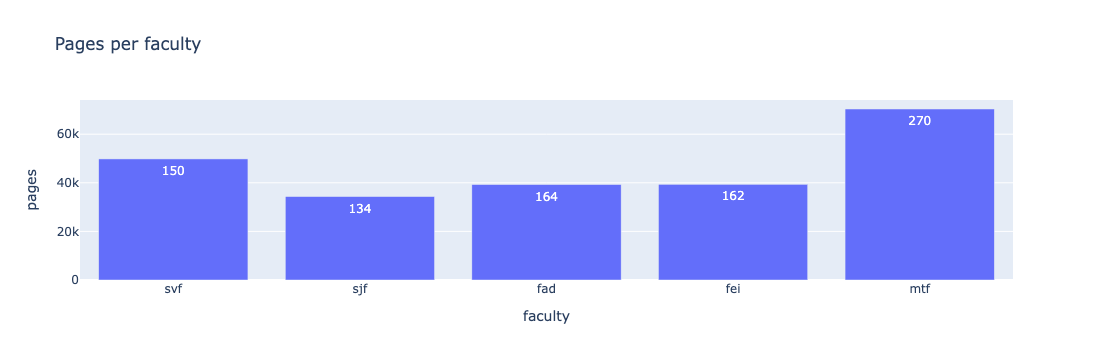

TOTAL: 880 books, 233183 pages, 6369.0 GB


,faculty,books,pages,GB
0,svf,150,49817,1443.0
1,sjf,134,34345,926.5
2,fad,164,39277,1151.9
3,fei,162,39377,1108.5
4,mtf,270,70367,1739.1


In [3]:
from evilflowers_books_digitalizer import LocalCache
from evilflowers_books_digitalizer.sources import build_source
cache = LocalCache(rt.cache_dir)
rows = []
for key in rt.source_keys:
    stats = cache.load_stats(key)
    if stats is not None:
        rows.append(dict(faculty=key, books=stats.n_books, pages=stats.n_pages,
                         GB=round(stats.total_bytes/1e9, 1)))
    else:
        try:
            rows.append(dict(faculty=key, books=len(build_source(rt.source, key).list_books()),
                             pages=None, GB=None))
        except Exception as exc:  # noqa: BLE001
            print(f'{key}: {exc}')
inv = pd.DataFrame(rows)
if not inv.empty and inv['pages'].notna().any():
    display(px.bar(inv, x='faculty', y='pages', title='Pages per faculty', text='books'))
    print('TOTAL:', int(inv['books'].sum()), 'books,',
          int(inv['pages'].fillna(0).sum()), 'pages,',
          round(inv['GB'].fillna(0).sum(), 1), 'GB')
else:
    print('No cached stats — run notebook 01 for pages/GB. Book counts:')
inv

## 2 · Metadata catalogue & ISBN enrichment
Reads `configs/catalog.xlsx` if the librarians have returned it, else the auto-generated `configs/catalog_template.xlsx` (notebook 10). Shows how much is auto-filled and from where.

catalog_template.xlsx: 880 books, 670 auto-filled (76%)


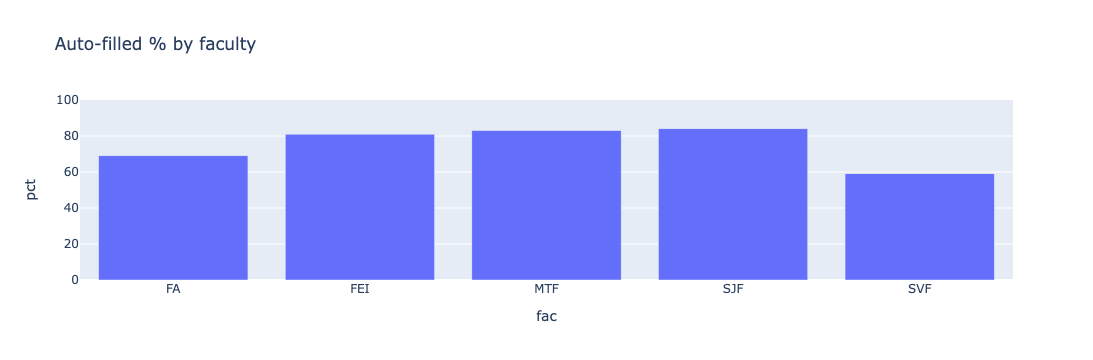

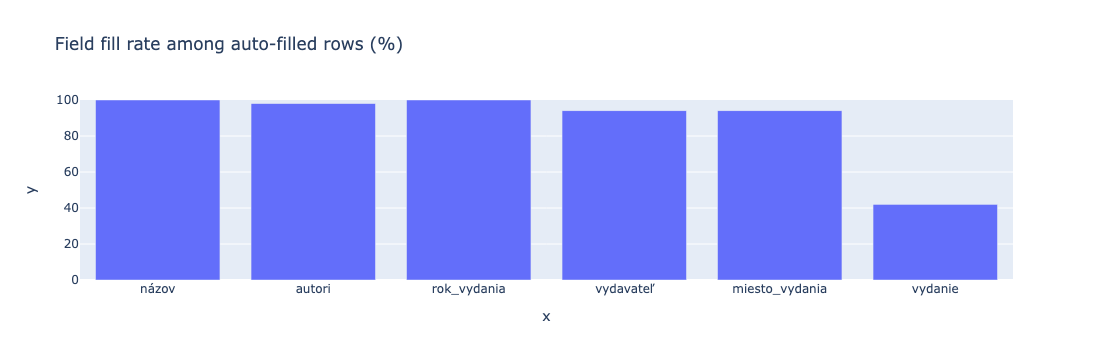

provider: {'STU IPAC': 670}


In [4]:
cat_path = next((Path(p) for p in ['configs/catalog.xlsx', 'configs/catalog_template.xlsx']
                 if Path(p).exists()), None)
if cat_path is None:
    print('No catalogue yet — run notebook 10 to draft it.')
else:
    cdf = pd.read_excel(cat_path, sheet_name='katalog', dtype=object)
    cdf['fac'] = cdf['directory_id'].str.extract(r'CVI_OPACID_([A-Z]+)_')
    cdf['auto'] = cdf['zdroj_metadat'].fillna('').astype(str).str.strip() != ''
    print(f'{cat_path.name}: {len(cdf)} books, '
          f"{cdf['auto'].sum()} auto-filled ({100*cdf['auto'].mean():.0f}%)")
    cov = cdf.groupby('fac')['auto'].agg(['sum','count'])
    cov['pct'] = (100*cov['sum']/cov['count']).round(0)
    display(px.bar(cov.reset_index(), x='fac', y='pct',
                   title='Auto-filled % by faculty', range_y=[0,100]))
    fields = ['názov','autori','rok_vydania','vydavateľ','miesto_vydania','vydanie']
    fill = {f: round(100*cdf.loc[cdf['auto'], f].notna().mean(), 0) for f in fields}
    display(px.bar(x=list(fill), y=list(fill.values()),
                   title='Field fill rate among auto-filled rows (%)', range_y=[0,100]))
    print('provider:', cdf.loc[cdf['auto'],'zdroj_metadat'].value_counts().to_dict())

## 3 · Cover sourcing projection
Books with an ISBN can get a **real OPAC cover** (~70 % hit rate via obalkyknih); the rest get a **generated** cover. Optionally sample the live cover service to estimate the real split.

In [5]:
from evilflowers_books_digitalizer.metadata.catalog import extract_dir_id
from evilflowers_books_digitalizer.metadata.isbn_lookup import is_valid_isbn
SAMPLE_LIVE = 0   # set e.g. 40 to probe obalkyknih live for a real-cover estimate
if cat_path is not None:
    ids = cdf['directory_id'].dropna().tolist()
    with_isbn = [b for b in ids if is_valid_isbn(extract_dir_id(b))]
    print(f'{len(with_isbn)}/{len(ids)} books have an ISBN -> eligible for a real OPAC cover')
    print(f'~{round(0.7*len(with_isbn))} real covers expected; the rest generated')
    if SAMPLE_LIVE:
        from evilflowers_books_digitalizer.covers import fetch_opac_cover
        import tempfile
        from evilflowers_books_digitalizer.metadata.catalog import normalize_id
        hits = 0
        for b in with_isbn[:SAMPLE_LIVE]:
            if fetch_opac_cover(extract_dir_id(b), Path(tempfile.mktemp(suffix='.jpg'))):
                hits += 1
        print(f'live sample: {hits}/{min(SAMPLE_LIVE, len(with_isbn))} have a real cover')

699/880 books have an ISBN -> eligible for a real OPAC cover
~489 real covers expected; the rest generated


## 4 · Batch results
From the JSONL reports under `output_dir`. Run notebook 11 (or a flow) first to have data here.

In [ ]:
raw = reporting.load_reports(rt.output_dir)
books = reporting.latest_per_book(raw)
if not books:
    print(f'No reports under {rt.output_dir} yet — run notebook 11 or a flow.')
else:
    summary = reporting.summarize_reports(books)
    print('OVERALL:', summary)
    df = pd.DataFrame(books)
    display(px.pie(df, names='status', title='Book status'))

In [ ]:
if books:
    ok = df[df['status'] == 'ok'].copy()
    if not ok.empty:
        display(px.histogram(ok, x='pdf_mb', nbins=30, title='PDF size (MB)'))
        if {'n_pages','minutes'} <= set(ok.columns):
            ok['mb_per_page'] = ok['pdf_mb'] / ok['n_pages']
            display(px.scatter(ok, x='n_pages', y='minutes', color='source',
                               hover_name='book_id', title='Pages vs processing minutes'))
        display(pd.DataFrame(reporting.summarize_by_source(books)).T)

## 5 · Sample produced artifacts (covers + a rendered page)

In [ ]:
covers = sorted(rt.output_dir.glob('*/*.cover.jpg'))[:8]
print(f'{len(list(rt.output_dir.glob("*/*.cover.jpg")))} covers produced')
if covers:
    from PIL import Image
    thumbs = [Image.open(c).convert('RGB').resize((150, 212)) for c in covers]
    sheet = Image.new('RGB', (160*len(thumbs)+10, 232), (240,240,240))
    x = 5
    for t in thumbs:
        sheet.paste(t, (x, 10)); x += 160
    display(sheet)

In [ ]:
pdfs = sorted(rt.output_dir.glob('*/*.pdf'))
if pdfs:
    import pypdfium2 as pdfium
    doc = pdfium.PdfDocument(str(pdfs[0]))
    print(pdfs[0].name, '-', len(doc), 'pages')
    display(doc[0].render(scale=110/72).to_pil())
else:
    print('No PDFs yet.')

---
Headless equivalent of section 4 (e.g. on the VM):
```bash
python -m evilflowers_books_digitalizer stats --config configs/pipeline.toml
```